This is a bootcamp covering all the pre-processing steps before giving to ML model.

Dataset: `insurance.csv`

In [ ]:
import pandas as pd

#load the dataset
df=pd.read_csv('/content/insurance (1).csv')

for big datasets present in drive this method uploading in colab will take time and wont happen
-mount - give file path in drive and then load

In [ ]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
#locate the file in the drive

file_path='/content/drive/MyDrive/ICT DSA Online/datasets/insurance (1).csv'
df=pd.read_csv(file_path)
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# Overall Flow for only Preprocessing section:
1. Understanding the data
2. Handling missing values
3. Handling duplicates
4. Detecting and Handling Outliers
5. Understanding Feature types
6. Encoding Categorical columns
7. Scaling and Normaliztion of Numerical columns
8. Correlation analysis
9. Preparing the final preprocessed dataset

# Section 1: Understanding the data

In [ ]:
#name of columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [ ]:
# view the first 3 rows
df.head(3)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46


In [ ]:
# view the last 5 rows
df.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [ ]:
#check the shape of the df
df.shape

(1338, 7)

In [ ]:
#general info regarding df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# basic statistics of df
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
# finding unique values of column=smoker
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df['smoker'].value_counts() # how many yes and no

,count
smoker,
no,1064
yes,274


In [ ]:
# find no.of unique values for category column=sex
df['sex'].nunique()

2

In [ ]:
# identify the target column='expenses' rest all features

# Section 2: Handling missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


# Section 3: Handling duplicates

In [ ]:
#no repeated records--> why?lead to bias learning

In [ ]:
#check for duplicated entries
df.duplicated().sum()

np.int64(1)

In [ ]:
# if duplictes exists here 1,its safe to drop duplicates
df.drop_duplicates(inplace=True)
# inplace is like writing df=df.drop_duplicates(),makes changes to original

In [ ]:
df.shape

(1337, 7)

# Section 4: Detecting and Handling Outliers

In [ ]:
#Outliers--> extreme values that can distort analysis and models
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

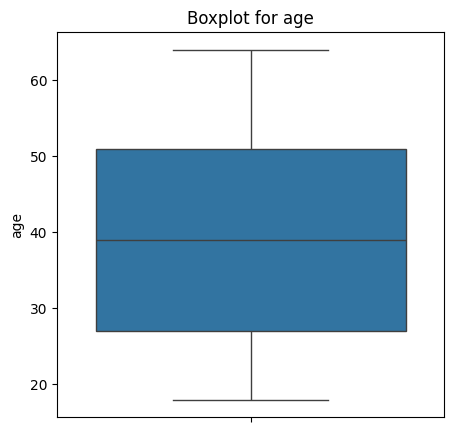

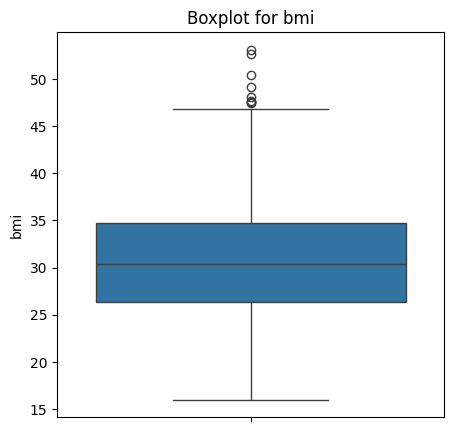

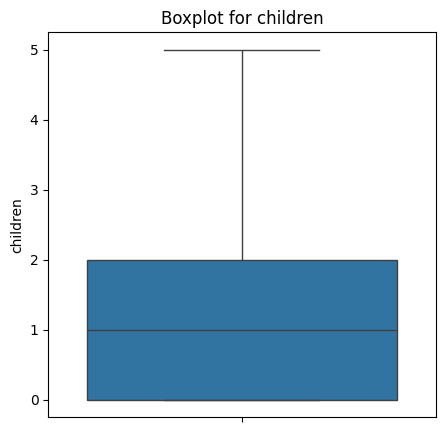

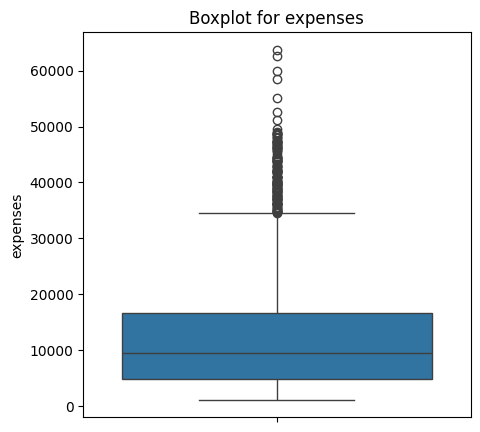

In [ ]:
# Focus on numeric columns: age,bmi,children,expenses not only for target if numeric all numeric columns shd check
# no outliers for categorical columns

#visualise boxplots
import seaborn as sns
import matplotlib.pyplot as plt

#boxplot for age,bmi,children and expenses
for col in ['age','bmi','children','expenses']:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(f'Boxplot for {col}')
  plt.show()

1. Is an oulier real or error?
2. will the oulier HURT the model or HELP the model?

In [ ]:
# column:BMI
# check if the outliers are realistic? medically possibe to have high values but error to have neagtive. --> these are REAL
#check distribution

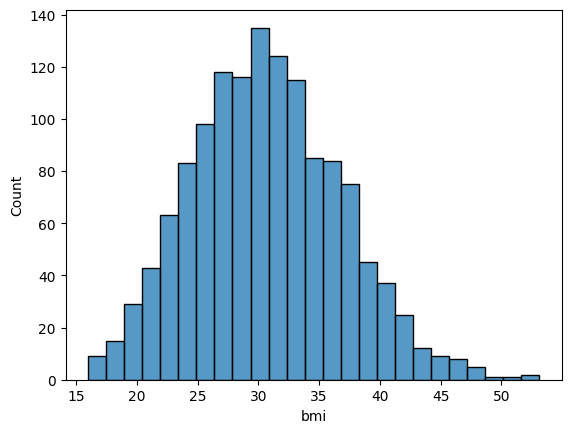

In [ ]:
sns.histplot(df['bmi'])
plt.show()

BMI roughly follows normal distribution

In [ ]:
# treat BMI columns only if the model needs it
# Linear models/KNN/SVm model---> outliers may distort
# Tree based models---> dont care abt outliers

In [ ]:
# Can do: IQR method of capping or z score sacling
# Cannot do: Log transform(BMI data is not skewed ie not cut) or remove rows blindly(lose real data )

In [ ]:
#column 2:'expenses'
# are the outliers real or error?: True readings not noise as there are ppl who give high expense insurance
# if column not real as in not posiible only then we can remove

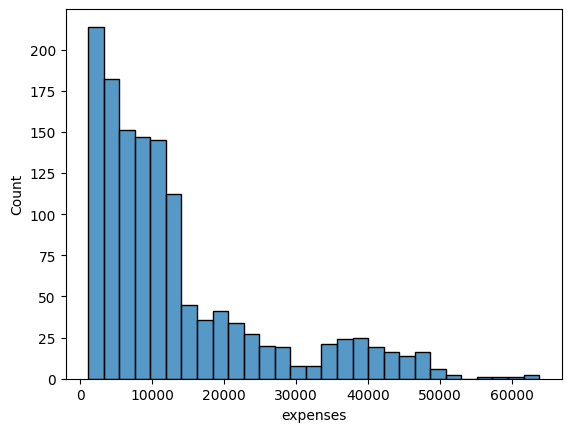

In [ ]:
#check distribution
sns.histplot(df['expenses'])
plt.show()

`'expenses'`
- highly right skewed
- long tail
- huge variance

In [ ]:
# will these outliers hurt the model?
# YES,highly skewed,treatment required

# what kind of treatment?
# For skewed feature,apply Log transformation
# will compress the long tail and makes the distribution closer to normal distribution

import numpy as np
df['expenses_log']=np.log(df['expenses']) # the new column is expenses's log and we will can deal with that its better

we see visualisation not only for outliers general understanding and filling also

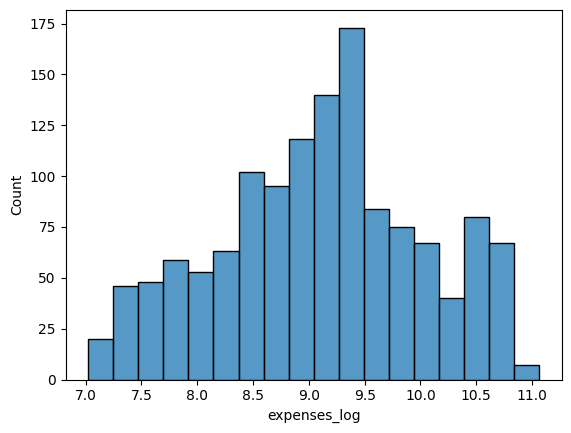

In [ ]:
# histogram 'expenses_log'
sns.histplot(df['expenses_log'])
plt.show()

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,expenses,expenses_log
0,19,female,27.9,0,yes,southwest,16884.92,9.734176
1,18,male,33.8,1,no,southeast,1725.55,7.453301
2,28,male,33.0,3,no,southeast,4449.46,8.400538
3,33,male,22.7,0,no,northwest,21984.47,9.998092
4,32,male,28.9,0,no,northwest,3866.86,8.260198


In [ ]:
# Column Type                             outlier Type                    Best Treatment
# Feature(input) if contribution        Very less outliers                 IQR Capping
# Feature(input)                       Highly skewed but meaningful        Log transform
# Target                                Real outliers but skewed           Log transform
# Any column                           Unreal values(negative height)      Remove that row
# Any column                               Rare but valid                  Keep them(they are signal)

# Section 5:Understanding Feature types

Goal: decide how each column will be treated henceforth

In [ ]:
# numerical columns: age,bmi,children and expenses # age and children no need visualization
# target column-->expenses

In [ ]:
# categorical columns: sex,smoker,region

Visual analysis: for all columns
- Univariate analysis---> understand each feature individually
- Bivariate analysis---> underatands each feature wrt target column(expenses)

<Axes: xlabel='age', ylabel='Count'>

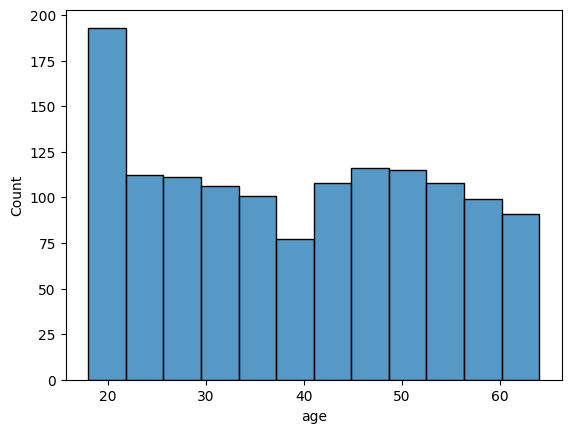

In [ ]:
# For univariate analysis:
#1. histplot(distribution shape)
#2. boxplot(outliers check)

#histplot on age
sns.histplot(df['age']) # to just see the range or variation in it

<Axes: xlabel='age', ylabel='expenses'>

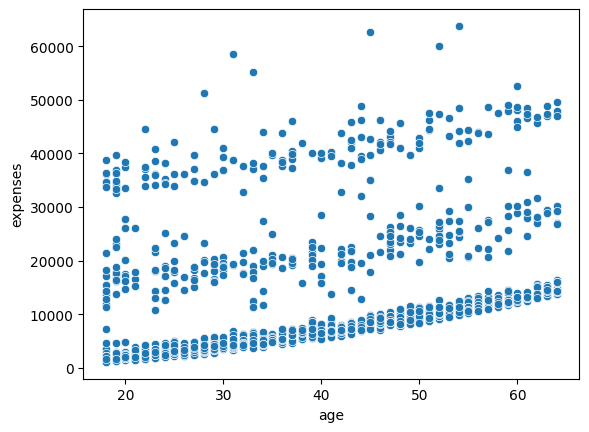

In [ ]:
#For bivariate analysis:
#1. Scatterplot(numerical feature+numerical target)
#2. regplot(numerical feature+numerical target)--->understand linear relatiosnhip/regression

#scatterplot b/w age and expenses
sns.scatterplot(x='age',y='expenses',data=df)

<Axes: xlabel='age', ylabel='expenses'>

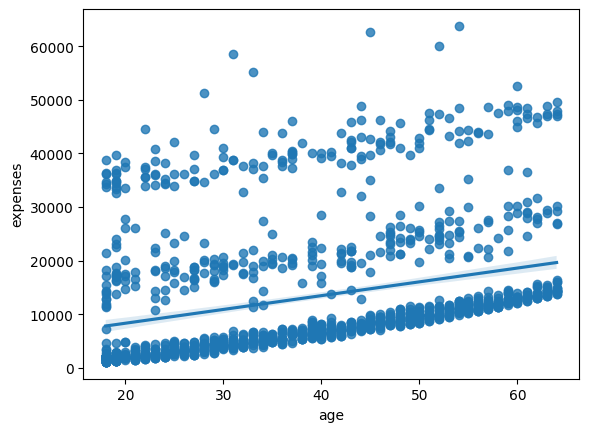

In [ ]:
sns.regplot(x='age',y='expenses',data=df)

<Axes: xlabel='bmi', ylabel='Count'>

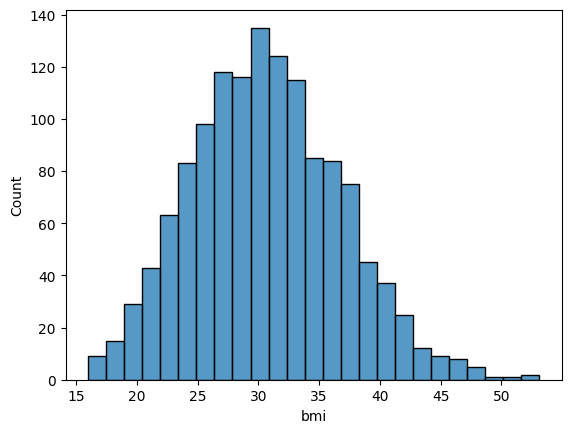

In [ ]:
sns.histplot(df['bmi'])

<Axes: xlabel='bmi', ylabel='expenses'>

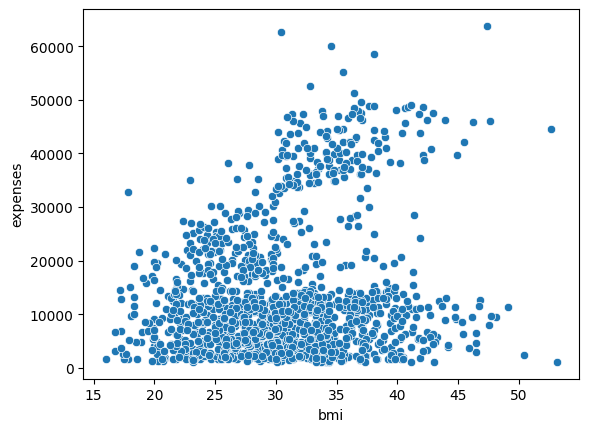

In [ ]:
sns.scatterplot(x='bmi',y='expenses',data=df)

<Axes: xlabel='bmi', ylabel='expenses'>

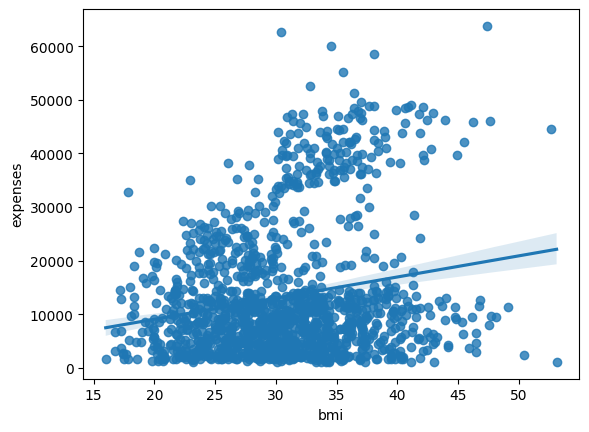

In [ ]:
sns.regplot(x='bmi',y='expenses',data=df)

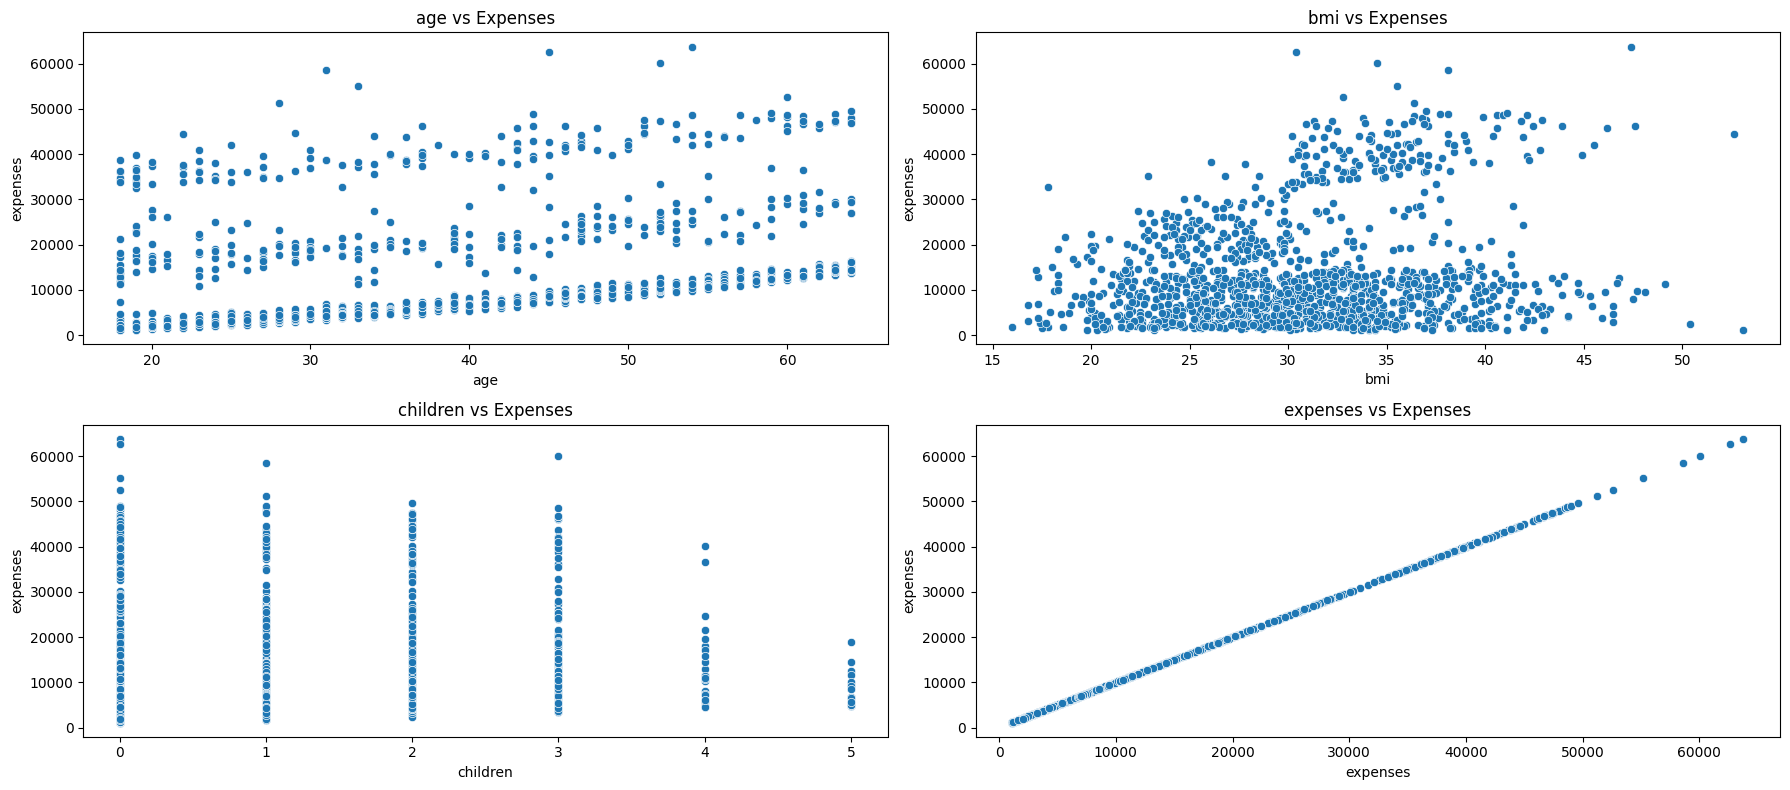

In [ ]:
# subplot for all numerical columns

num_col=['age','bmi','children','expenses']

plt.figure(figsize=(18,8))
for i,col in enumerate(num_col,1): # enumerate will give index stored in i and name in col 1 is step
  plt.subplot(2,2,i)
  sns.scatterplot(x=col,y='expenses',data=df)
  plt.title(f'{col} vs Expenses')

plt.tight_layout() # for subplot spacing default and ticks
plt.show()

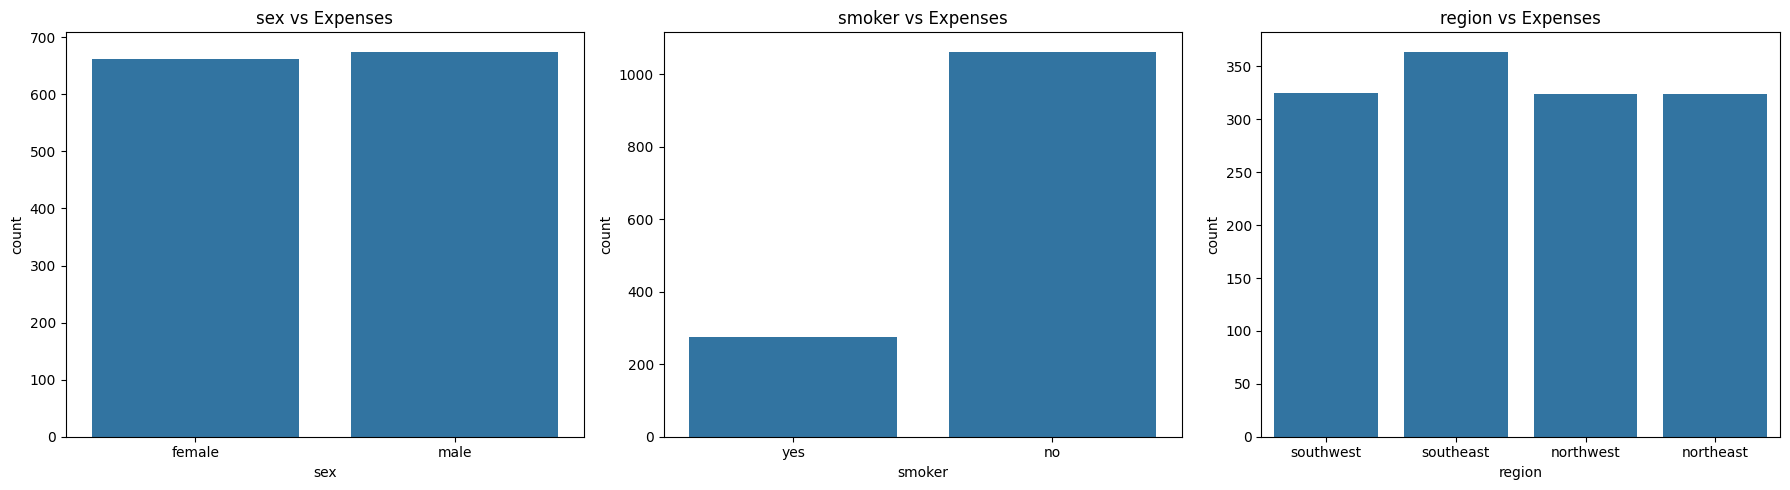

In [ ]:
# subplot for categorical columns- count plot to get count of each

cat_col=['sex','smoker','region']

plt.figure(figsize=(18,5))
for i,col in enumerate(cat_col,1):
  plt.subplot(1,3,i)
  sns.countplot(x=col,data=df)
  plt.title(f'{col} vs Expenses')

plt.tight_layout()

# Section 6: Encoding Categorical columns

In [ ]:
# 3 categorical columns which are nominal---> one hot
# Sex--->binary categories(F or M)
# smoker---> binary(yes or no)
# region---> nominal 4 categories

# Binary: instead of one_hot encoding since only two using map with astype as list indirect one hot given or works in form of label
# not correct should do one hot # because this assigns higher values to label
df['sex']=df['sex'].map({'female':0,'male':1}).astype(int)
df['smoker']=df['smoker'].map({'no':0,'yes':1}).astype(int)

#nominal feature : region ---> one hot encoding
df=pd.get_dummies(df,columns=['region'],drop_first=True)
one_hot_col=[col for col in df.columns if 'region_' in col] # if it starts with region_then those are the dummies columns to be encoded in one hot format
df[one_hot_col]=df[one_hot_col].astype(int) # since one hot and in other way also works like this

In [ ]:
df.head()

,age,sex,bmi,children,smoker,expenses,expenses_lof,expenses_log,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,9.734176,9.734176,0,0,1
1,18,1,33.8,1,0,1725.55,7.453301,7.453301,0,1,0
2,28,1,33.0,3,0,4449.46,8.400538,8.400538,0,1,0
3,33,1,22.7,0,0,21984.47,9.998092,9.998092,1,0,0
4,32,1,28.9,0,0,3866.86,8.260198,8.260198,1,0,0


# Section 7: Scaling and Normaliztion of Numerical columns

Because different numerical features:
- measured in different units
- different ranges

Examples:
- BMI might change 14-45
- Age between 18-70

Without scaling:
- expenses dominates everything
- models can misintrepret features importance

In [ ]:
# 1. Z score standardization
#       data has normal distribution
#       values to be centered
#       keeps outliers inside it

# 2. Min-max scaling

# those encoded need not be scaled only if required and that too in label encoding
# Age: roughly uniform not bell or skew--->stdScaler works
#BMI: slightly skew---> stdScaler works
# children: small range---> stdScaler
#expenses:skewed---> log transformed it already so no need scaling as we are using that log value which is already scaled like range

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

num_cols=['age','bmi','children']
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()

,age,sex,bmi,children,smoker,expenses,expenses_log,region_northwest,region_southeast,region_southwest
0,-1.440418,0,-0.453484,-0.909234,1,16884.92,9.734176,0,0,1
1,-1.511647,1,0.513986,-0.079442,0,1725.55,7.453301,0,1,0
2,-0.799350,1,0.382803,1.580143,0,4449.46,8.400538,0,1,0
3,-0.443201,1,-1.306169,-0.909234,0,21984.47,9.998092,1,0,0
4,-0.514431,1,-0.289506,-0.909234,0,3866.86,8.260198,1,0,0


# Section 8: Correlation analysis

which feature has the strongest relationship with the target(expenses)

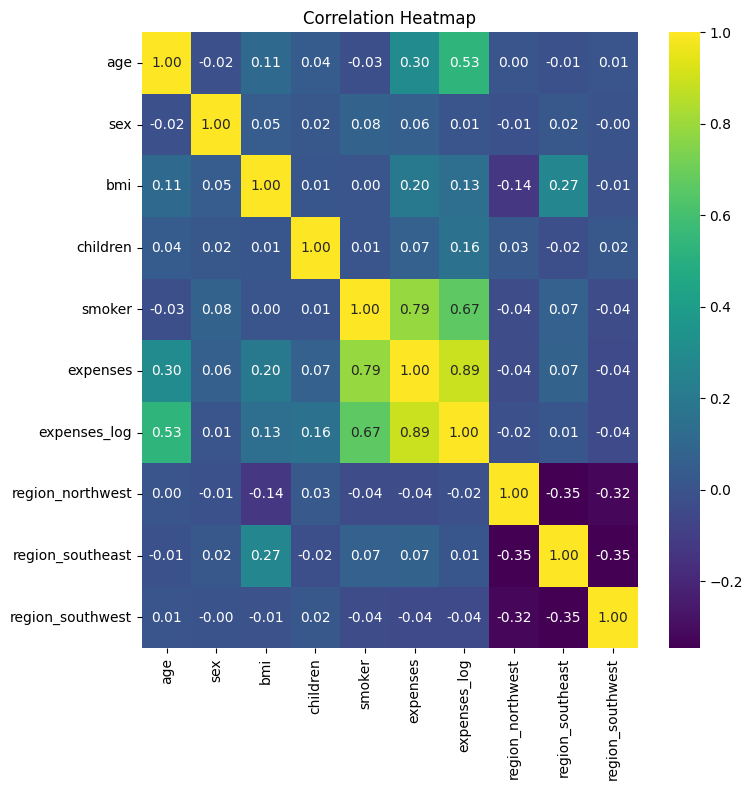

In [ ]:
corr=df.corr()
# at present what all features are there in df so do correlation after removing the unnecessary columns
#heatmap
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=True, fmt='0.2f',cmap = 'viridis')
plt.title('Correlation Heatmap')
plt.show()

# Section 9: Preparing the final preprocessed dataset

In [ ]:
# target column --> expenses_log

# final features
final_features = [
    'age', 'sex','bmi', 'children', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest']

X = df[final_features]  # all features
y = df['expenses_log']  # target column

In [ ]:
X # full cleaned,analysed,encoded and scaled